# NIH Chest X-ray 14 — DenseNet121 Multi-Label Classification + Grad-CAM

This notebook trains a pretrained DenseNet121 on the NIH ChestX-ray14 dataset, evaluates 14 disease labels, saves the model as `.pt` and `.pkl`, and generates disease probabilities and class-specific Grad-CAM heatmaps.

**Medical/research note:** This is an educational/research baseline, not a clinically validated diagnostic system. Model probabilities and Grad-CAM visualizations should not be treated as medical diagnoses.

In [8]:
import os
import copy
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import densenet121, DenseNet121_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [9]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.13.0+cpu
Device: cpu


## 1. Configure the dataset path

Change `DATA_DIR` to the folder containing `Data_Entry_2017.csv`, the train/test list files, and the `images-224` directory.

In [10]:
DATA_DIR = r"D:/MedVision_Ai/backend/dataset/chest_xray"

CSV_FILE = os.path.join(DATA_DIR, "Data_Entry_2017.csv")
IMAGE_DIR = os.path.join(DATA_DIR, "images-224", "images-224")
TRAIN_LIST = os.path.join(DATA_DIR, "train_val_list_NIH.txt")
TEST_LIST = os.path.join(DATA_DIR, "test_list_NIH.txt")

print("CSV:", CSV_FILE)
print("Images:", IMAGE_DIR)
print("Train list:", TRAIN_LIST)
print("Test list:", TEST_LIST)

print("\nPath checks:")
print("CSV exists:", os.path.exists(CSV_FILE))
print("Image folder exists:", os.path.exists(IMAGE_DIR))
print("Train list exists:", os.path.exists(TRAIN_LIST))
print("Test list exists:", os.path.exists(TEST_LIST))

CSV: D:/MedVision_Ai/backend/dataset/chest_xray\Data_Entry_2017.csv
Images: D:/MedVision_Ai/backend/dataset/chest_xray\images-224\images-224
Train list: D:/MedVision_Ai/backend/dataset/chest_xray\train_val_list_NIH.txt
Test list: D:/MedVision_Ai/backend/dataset/chest_xray\test_list_NIH.txt

Path checks:
CSV exists: True
Image folder exists: True
Train list exists: True
Test list exists: True


In [11]:
CLASS_NAMES = [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural_Thickening",
    "Hernia",
]

NUM_CLASSES = len(CLASS_NAMES)

print("Number of classes:", NUM_CLASSES)
print(CLASS_NAMES)

Number of classes: 14
['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']


In [12]:
df = pd.read_csv(CSV_FILE)

print("Rows:", len(df))
print("Columns:")
print(df.columns.tolist())

display(df[["Image Index", "Finding Labels", "Patient ID"]].head())

Rows: 112120
Columns:
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']


,Image Index,Finding Labels,Patient ID
0,00000001_000.png,Cardiomegaly,1
1,00000001_001.png,Cardiomegaly|Emphysema,1
2,00000001_002.png,Cardiomegaly|Effusion,1
3,00000002_000.png,No Finding,2
4,00000003_000.png,Hernia,3


In [13]:
# Convert the pipe-separated Finding Labels column into 14 binary targets.

for disease in CLASS_NAMES:
    df[disease] = 0

for index, labels in df["Finding Labels"].items():
    for label in str(labels).split("|"):
        if label in CLASS_NAMES:
            df.loc[index, label] = 1

display(df[["Image Index", "Finding Labels"] + CLASS_NAMES].head())

,Image Index,Finding Labels,Atelectasis,Cardiomegaly,Effusion,Infiltration,Mass,Nodule,Pneumonia,Pneumothorax,Consolidation,Edema,Emphysema,Fibrosis,Pleural_Thickening,Hernia
0,00000001_000.png,Cardiomegaly,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,0,1,0,0,0,0,0,0,0,0,1,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,0,1,1,0,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,No Finding,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,00000003_000.png,Hernia,0,0,0,0,0,0,0,0,0,0,0,0,0,1


,Image count
Infiltration,19870
Effusion,13307
Atelectasis,11535
Nodule,6323
Mass,5746
Pneumothorax,5298
Consolidation,4667
Pleural_Thickening,3385
Cardiomegaly,2772
Emphysema,2516


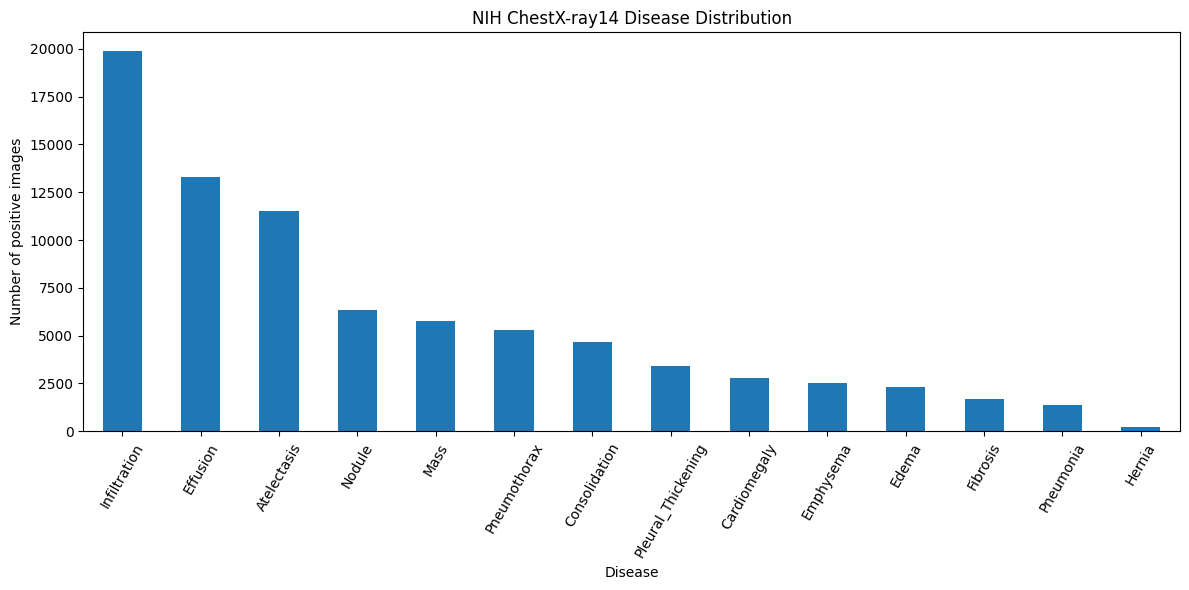

In [14]:
disease_counts = df[CLASS_NAMES].sum().sort_values(ascending=False)

display(disease_counts.to_frame("Image count"))

plt.figure(figsize=(12, 6))
disease_counts.plot(kind="bar")
plt.title("NIH ChestX-ray14 Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of positive images")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [15]:
with open(TRAIN_LIST, "r") as f:
    train_images = [line.strip() for line in f if line.strip()]

with open(TEST_LIST, "r") as f:
    test_images = [line.strip() for line in f if line.strip()]

train_df = df[df["Image Index"].isin(train_images)].copy()
test_df = df[df["Image Index"].isin(test_images)].copy()

print("Official train/validation images:", len(train_df))
print("Official test images:", len(test_df))

Official train/validation images: 86524
Official test images: 25596


## 2. Patient-wise train/validation split

The split is performed at patient level to reduce the risk of having images from the same patient in both training and validation sets.

In [16]:
patients = train_df["Patient ID"].unique()

train_patients, val_patients = train_test_split(
    patients,
    test_size=0.15,
    random_state=SEED
)

train_df_final = train_df[
    train_df["Patient ID"].isin(train_patients)
].copy()

val_df = train_df[
    train_df["Patient ID"].isin(val_patients)
].copy()

print("Train patients:", len(train_patients))
print("Validation patients:", len(val_patients))
print("Train images:", len(train_df_final))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Train patients: 23806
Validation patients: 4202
Train images: 73916
Validation images: 12608
Test images: 25596


In [17]:
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=5),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [18]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = os.path.join(
            self.image_dir,
            row["Image Index"]
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = row[CLASS_NAMES].values.astype(np.float32)
        labels = torch.tensor(labels, dtype=torch.float32)

        return image, labels

In [19]:
train_dataset = ChestXrayDataset(
    train_df_final,
    IMAGE_DIR,
    train_transform
)

val_dataset = ChestXrayDataset(
    val_df,
    IMAGE_DIR,
    val_transform
)

test_dataset = ChestXrayDataset(
    test_df,
    IMAGE_DIR,
    val_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 73916
Validation: 12608
Test: 25596


In [27]:
BATCH_SIZE = 24

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

images, labels = next(iter(train_loader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)

Image batch: torch.Size([24, 3, 224, 224])
Label batch: torch.Size([24, 14])


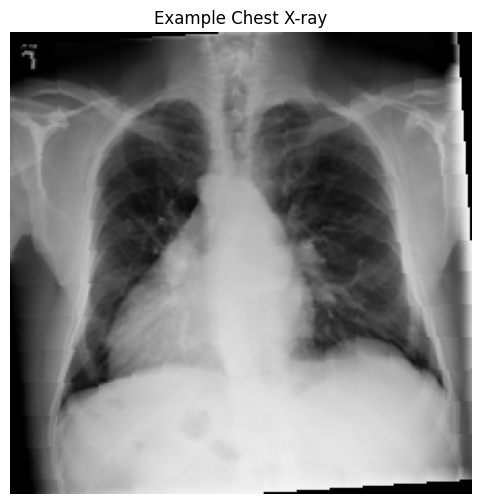

Positive labels:
- Cardiomegaly


In [28]:
# Display one training example.

image, label = train_dataset[0]

display_image = image.permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
display_image = np.clip(display_image * std + mean, 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(display_image, cmap="gray")
plt.axis("off")
plt.title("Example Chest X-ray")
plt.show()

print("Positive labels:")
for i, value in enumerate(label.numpy()):
    if value == 1:
        print("-", CLASS_NAMES[i])

## 3. DenseNet121 model

The final classifier is changed from ImageNet's 1000 classes to 14 independent disease outputs. Because this is multi-label classification, the training loss is `BCEWithLogitsLoss`.

In [29]:
weights = DenseNet121_Weights.DEFAULT

model = densenet121(weights=weights)

num_features = model.classifier.in_features

model.classifier = nn.Linear(
    num_features,
    NUM_CLASSES
)

model = model.to(device)

print(model.classifier)

Linear(in_features=1024, out_features=14, bias=True)


In [30]:
# Positive-class weighting for the strong class imbalance.

positive_counts = train_df_final[CLASS_NAMES].sum()
negative_counts = len(train_df_final) - positive_counts

pos_weight = negative_counts / positive_counts

pos_weight = torch.tensor(
    pos_weight.values,
    dtype=torch.float32,
).to(device)

display(
    pd.DataFrame({
        "Disease": CLASS_NAMES,
        "Positive count": positive_counts.values,
        "Positive weight": pos_weight.cpu().numpy(),
    })
)

,Disease,Positive count,Positive weight
0,Atelectasis,7003,9.554905
1,Cardiomegaly,1453,49.871300
2,Effusion,7415,8.968442
3,Infiltration,11853,5.236058
4,Mass,3452,20.412514
5,Nodule,4042,17.286987
6,Pneumonia,742,98.617249
7,Pneumothorax,2287,31.320070
8,Consolidation,2482,28.780823
9,Edema,1201,60.545380


In [31]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [32]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    progress = tqdm(loader, desc="Training")

    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        progress.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / len(loader.dataset)


def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probabilities = torch.sigmoid(outputs)

            running_loss += loss.item() * images.size(0)

            all_labels.append(labels.cpu().numpy())
            all_probs.append(probabilities.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)

    return epoch_loss, all_labels, all_probs


def calculate_mean_auc(labels, probabilities):
    aucs = []

    for i in range(NUM_CLASSES):
        try:
            auc = roc_auc_score(labels[:, i], probabilities[:, i])
            aucs.append(auc)
        except ValueError:
            pass

    return float(np.mean(aucs))

## 4. Train

Start with 5 epochs to verify that the complete pipeline works. After that, increase `EPOCHS` if needed.

In [ ]:
EPOCHS = 5

best_auc = 0.0
best_model_weights = copy.deepcopy(model.state_dict())

history = {
    "train_loss": [],
    "val_loss": [],
    "val_auc": [],
}

for epoch in range(EPOCHS):
    print(f"\n========== Epoch {epoch + 1}/{EPOCHS} ==========")

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_labels, val_probs = validate(
        model,
        val_loader,
        criterion,
        device
    )

    val_auc = calculate_mean_auc(
        val_labels,
        val_probs
    )

    scheduler.step(val_auc)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")
    print(f"Validation mean AUROC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        best_model_weights = copy.deepcopy(model.state_dict())
        print("✓ Best model updated")


========== Epoch 1/5 ==========


Training:   0%|          | 0/3080 [00:00<?, ?it/s]

In [ ]:
model.load_state_dict(best_model_weights)

print(f"Best validation mean AUROC: {best_auc:.4f}")

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], marker="o", label="Train Loss")
plt.plot(history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["val_auc"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Mean AUROC")
plt.title("Validation Mean AUROC")
plt.show()

## 5. Test evaluation

In [ ]:
test_loss, test_labels, test_probs = validate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test loss: {test_loss:.4f}")

In [ ]:
test_aucs = {}
test_auprcs = {}

for i, disease in enumerate(CLASS_NAMES):
    try:
        test_aucs[disease] = roc_auc_score(
            test_labels[:, i],
            test_probs[:, i]
        )
    except ValueError:
        test_aucs[disease] = np.nan

    try:
        test_auprcs[disease] = average_precision_score(
            test_labels[:, i],
            test_probs[:, i]
        )
    except ValueError:
        test_auprcs[disease] = np.nan

metrics_df = pd.DataFrame({
    "Disease": CLASS_NAMES,
    "AUROC": [test_aucs[d] for d in CLASS_NAMES],
    "AUPRC": [test_auprcs[d] for d in CLASS_NAMES],
})

display(metrics_df)

print("Mean AUROC:", np.nanmean(metrics_df["AUROC"]))
print("Mean AUPRC:", np.nanmean(metrics_df["AUPRC"]))

In [ ]:
THRESHOLD = 0.5

test_predictions = (
    test_probs >= THRESHOLD
).astype(int)

rows = []

for i, disease in enumerate(CLASS_NAMES):
    rows.append({
        "Disease": disease,
        "Precision": precision_score(
            test_labels[:, i],
            test_predictions[:, i],
            zero_division=0
        ),
        "Recall": recall_score(
            test_labels[:, i],
            test_predictions[:, i],
            zero_division=0
        ),
        "F1": f1_score(
            test_labels[:, i],
            test_predictions[:, i],
            zero_division=0
        ),
        "AUROC": test_aucs[disease],
        "AUPRC": test_auprcs[disease],
    })

metrics_df = pd.DataFrame(rows)
display(metrics_df)

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_df, x="Disease", y="AUROC")
plt.ylim(0, 1)
plt.xticks(rotation=60)
plt.title("Test AUROC by Disease")
plt.tight_layout()
plt.show()

## 6. Save the trained model as `.pt` and `.pkl`

In [ ]:
PT_FILE = "chest_xray14_densenet121.pt"

checkpoint = {
    "architecture": "densenet121",
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "model_state_dict": model.state_dict(),
    "best_val_auc": best_auc,
    "input_size": 224,
    "threshold": THRESHOLD,
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
}

torch.save(checkpoint, PT_FILE)

print("Saved:", os.path.abspath(PT_FILE))

In [ ]:
PKL_FILE = "chest_xray14_densenet121.pkl"

model_data = {
    "architecture": "densenet121",
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "model_state_dict": model.state_dict(),
    "best_val_auc": best_auc,
    "input_size": 224,
    "threshold": THRESHOLD,
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
}

with open(PKL_FILE, "wb") as f:
    pickle.dump(model_data, f)

print("Saved:", os.path.abspath(PKL_FILE))

metrics_df.to_csv(
    "chest_xray_metrics.csv",
    index=False
)

## 7. Load a saved `.pt` model

Run this section if you are starting a new kernel/session and want to load the trained model.

In [ ]:
def load_saved_pt_model(
    path,
    device
):
    checkpoint = torch.load(
        path,
        map_location=device,
        weights_only=False
    )

    loaded_model = densenet121(weights=None)

    loaded_model.classifier = nn.Linear(
        loaded_model.classifier.in_features,
        checkpoint["num_classes"]
    )

    loaded_model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    loaded_model = loaded_model.to(device)
    loaded_model.eval()

    return loaded_model, checkpoint


# Example:
# model, checkpoint = load_saved_pt_model(
#     "chest_xray14_densenet121.pt",
#     device
# )

## 8. Predict diseases and probabilities for one X-ray

In [ ]:
def predict_xray(
    image_path,
    model,
    transform,
    device,
    class_names,
    threshold=0.5
):
    image = Image.open(image_path).convert("RGB")

    input_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.sigmoid(output)[0].cpu().numpy()

    results = pd.DataFrame({
        "Disease": class_names,
        "Probability": probabilities,
        "Probability (%)": probabilities * 100,
    })

    results["Prediction"] = np.where(
        results["Probability"] >= threshold,
        "Positive",
        "Negative"
    )

    results = results.sort_values(
        "Probability",
        ascending=False
    ).reset_index(drop=True)

    return image, input_tensor, results


# Change this path:
IMAGE_PATH = r"D:\ChestXray14\images-224\images-224 00001_000.png"

# Example:
# original_image, input_tensor, prediction_df = predict_xray(
#     IMAGE_PATH,
#     model,
#     val_transform,
#     device,
#     CLASS_NAMES,
#     threshold=0.5
# )
# display(prediction_df)

## 9. Grad-CAM heatmaps

Grad-CAM is generated separately for each selected disease. The heatmap shows image regions associated with the selected model output; it is an interpretability visualization, not a proof of disease.

In [ ]:
def analyze_xray_with_gradcam(
    image_path,
    model,
    transform,
    device,
    class_names,
    top_k=3,
    threshold=0.5
):
    original_image = Image.open(
        image_path
    ).convert("RGB")

    input_tensor = transform(
        original_image
    ).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.sigmoid(
            output
        )[0].cpu().numpy()

    results = pd.DataFrame({
        "Disease": class_names,
        "Probability": probabilities,
        "Probability (%)": probabilities * 100,
    })

    results["Prediction"] = np.where(
        results["Probability"] >= threshold,
        "Positive",
        "Negative"
    )

    results = results.sort_values(
        "Probability",
        ascending=False
    ).reset_index(drop=True)

    target_layers = [
        model.features.denseblock4
    ]

    cam = GradCAM(
        model=model,
        target_layers=target_layers
    )

    rgb_image = np.array(
        original_image.resize((224, 224))
    ).astype(np.float32) / 255.0

    top_indices = np.argsort(
        probabilities
    )[::-1][:top_k]

    heatmaps = []

    for class_index in top_indices:
        disease = class_names[class_index]
        probability = probabilities[class_index]

        targets = [
            ClassifierOutputTarget(class_index)
        ]

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]

        visualization = show_cam_on_image(
            rgb_image,
            grayscale_cam,
            use_rgb=True
        )

        heatmaps.append({
            "disease": disease,
            "class_index": int(class_index),
            "probability": float(probability),
            "image": visualization,
        })

    return (
        original_image,
        results,
        heatmaps
    )

In [ ]:
# Run the complete prediction + Grad-CAM analysis.
#
# Change IMAGE_PATH first.

# original_image, prediction_df, heatmaps = analyze_xray_with_gradcam(
#     IMAGE_PATH,
#     model,
#     val_transform,
#     device,
#     CLASS_NAMES,
#     top_k=3,
#     threshold=0.5
# )
#
# display(prediction_df)

In [ ]:
# Display top predicted diseases and their Grad-CAM heatmaps.

# print("Top predictions:")
# display(
#     prediction_df.head(5)[
#         ["Disease", "Probability (%)", "Prediction"]
#     ]
# )

# for item in heatmaps:
#     print(
#         f"{item['disease']}: "
#         f"{item['probability'] * 100:.2f}%"
#     )
#
#     plt.figure(figsize=(7, 7))
#     plt.imshow(item["image"])
#     plt.title(
#         f"{item['disease']} — "
#         f"{item['probability'] * 100:.2f}%"
#     )
#     plt.axis("off")
#     plt.show()

In [ ]:
# Save Grad-CAM images.

def save_gradcam_results(
    heatmaps,
    output_dir="gradcam_results"
):
    os.makedirs(output_dir, exist_ok=True)

    saved_files = []

    for item in heatmaps:
        filename = (
            item["disease"]
            .replace(" ", "_")
            .lower()
            + "_gradcam.jpg"
        )

        filepath = os.path.join(
            output_dir,
            filename
        )

        cv2.imwrite(
            filepath,
            cv2.cvtColor(
                item["image"],
                cv2.COLOR_RGB2BGR
            )
        )

        saved_files.append(filepath)

    return saved_files


# Example:
# saved_files = save_gradcam_results(heatmaps)
# print("\n".join(saved_files))

## Expected outputs

After successful training and inference, the notebook can produce:

- `chest_xray14_densenet121.pt` — PyTorch checkpoint
- `chest_xray14_densenet121.pkl` — pickled checkpoint metadata/state
- `chest_xray_metrics.csv` — per-disease evaluation metrics
- `gradcam_results/*.jpg` — class-specific Grad-CAM heatmaps

For a new X-ray, the prediction table contains all 14 disease probabilities, and Grad-CAM can be generated for the top predicted diseases.